<a href="https://colab.research.google.com/github/RKlavins/Markets-Strategies/blob/main/options_volatility_surface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime
from mpl_toolkits.mplot3d import Axes3D

# --- Pull SPY options across all expiries ---
ticker  = yf.Ticker("SPY")
S       = ticker.history(period='1d')['Close'].iloc[-1]
r       = 0.05
today   = datetime.now()

print(f"Current SPY price: ${S:.2f}")
print(f"Available expiries: {ticker.options[:15]}")

Current SPY price: $744.78
Available expiries: ('2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-07', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30')


In [ ]:
# --- Collect implied vol across all strikes and expiries ---
surface_data = []

for expiry in ticker.options[:12]:  # first 12 expiries
    try:
        expiry_dt = datetime.strptime(expiry, '%Y-%m-%d')
        T = (expiry_dt - today).days / 365

        if T <= 0:
            continue

        chain = ticker.option_chain(expiry)
        calls = chain.calls.copy()

        # Filter — liquid options near the money
        calls = calls[
            (calls['strike'] > S * 0.80) &
            (calls['strike'] < S * 1.20) &
            (calls['impliedVolatility'] > 0.01) &
            (calls['impliedVolatility'] < 2.0) &
            (calls['volume'] > 0)
        ]

        for _, row in calls.iterrows():
            # Convert strike to moneyness — % away from current price
            moneyness = (row['strike'] - S) / S * 100
            surface_data.append({
                'Expiry':     expiry,
                'Days':       (expiry_dt - today).days,
                'Strike':     row['strike'],
                'Moneyness':  moneyness,
                'IV':         row['impliedVolatility'] * 100,
                'Volume':     row['volume']
            })

        print(f"✓ {expiry} — {len(calls)} strikes, T={T:.2f}yr")

    except Exception as e:
        print(f"✗ {expiry}: {e}")

df = pd.DataFrame(surface_data)
print(f"\nTotal data points: {len(df)}")
print(df.head())

✓ 2026-07-06 — 94 strikes, T=0.00yr
✓ 2026-07-07 — 81 strikes, T=0.01yr
✓ 2026-07-08 — 73 strikes, T=0.01yr
✓ 2026-07-09 — 68 strikes, T=0.01yr
✓ 2026-07-10 — 169 strikes, T=0.01yr
✓ 2026-07-17 — 167 strikes, T=0.03yr
✓ 2026-07-24 — 151 strikes, T=0.05yr
✓ 2026-07-31 — 201 strikes, T=0.07yr
✓ 2026-08-07 — 92 strikes, T=0.09yr
✓ 2026-08-21 — 174 strikes, T=0.13yr
✓ 2026-08-31 — 195 strikes, T=0.16yr
✓ 2026-09-18 — 168 strikes, T=0.21yr

Total data points: 1633
       Expiry  Days  Strike  Moneyness          IV  Volume
0  2026-07-06     1   625.0 -16.082605  118.213300    30.0
1  2026-07-06     1   660.0 -11.383231   87.817505     6.0
2  2026-07-06     1   665.0 -10.711892   83.471845     2.0
3  2026-07-06     1   670.0 -10.040552   79.101771     2.0
4  2026-07-06     1   700.0  -6.012517   52.710434   122.0


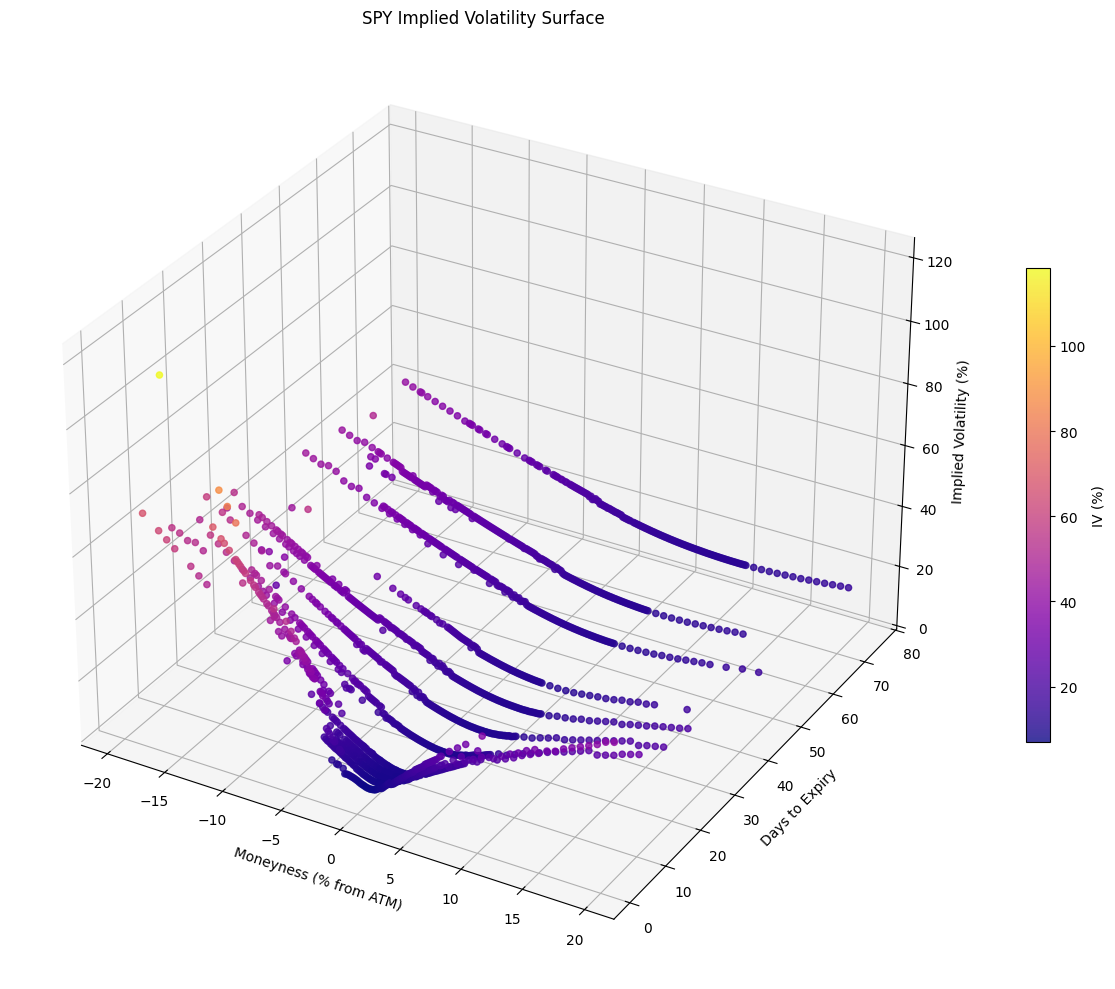

In [ ]:
# --- Plot the 3D volatility surface ---
fig = plt.figure(figsize=(14, 10))
ax  = fig.add_subplot(111, projection='3d')

# Pivot to grid format
pivot = df.groupby(['Days', 'Moneyness'])['IV'].mean().reset_index()

X = pivot['Moneyness'].values
Y = pivot['Days'].values
Z = pivot['IV'].values

scatter = ax.scatter(X, Y, Z, c=Z, cmap='plasma', s=20, alpha=0.8)

ax.set_xlabel('Moneyness (% from ATM)')
ax.set_ylabel('Days to Expiry')
ax.set_zlabel('Implied Volatility (%)')
ax.set_title('SPY Implied Volatility Surface')

plt.colorbar(scatter, ax=ax, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()

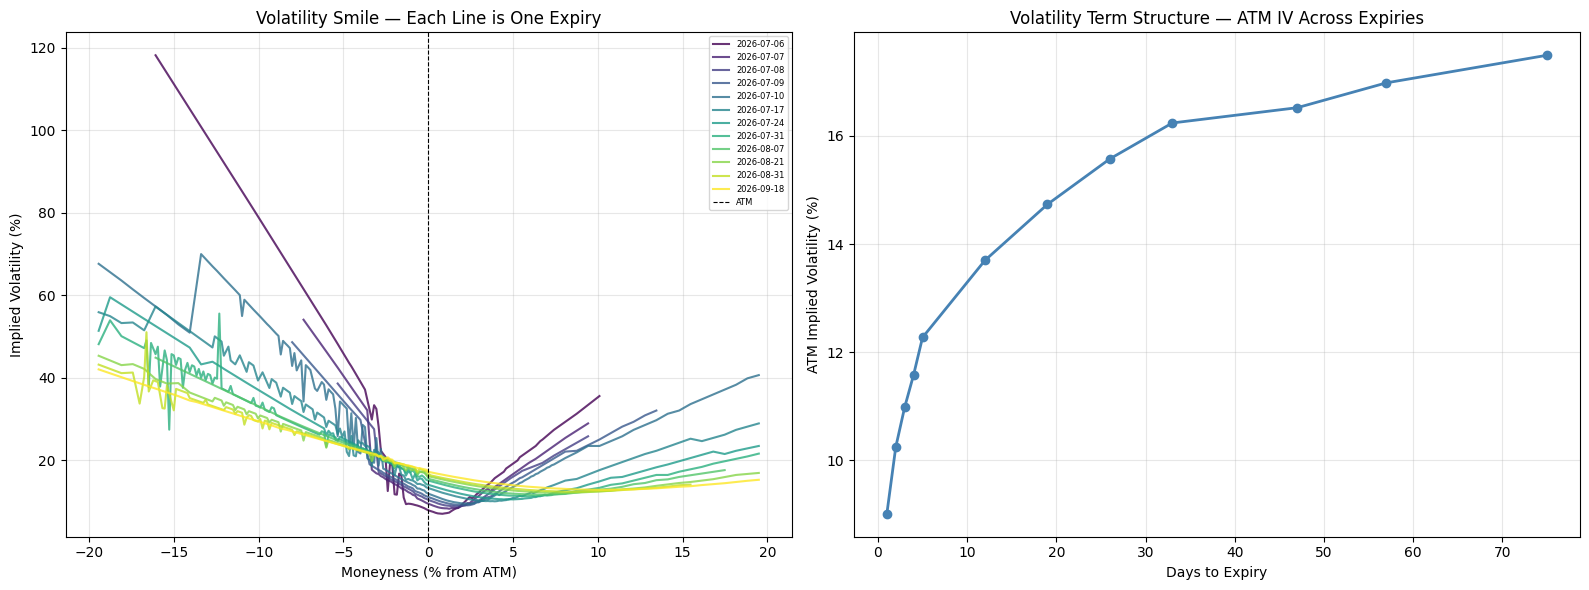

ATM Volatility Term Structure:
----------------------------------------
    1 days: 9.0%
    2 days: 10.2%
    3 days: 11.0%
    4 days: 11.6%
    5 days: 12.3%
   12 days: 13.7%
   19 days: 14.7%
   26 days: 15.6%
   33 days: 16.2%
   47 days: 16.5%
   57 days: 17.0%
   75 days: 17.5%


In [ ]:
# --- 2D slices — more readable ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Slice 1 — Volatility smile at different expiries
expiry_groups = df.groupby('Expiry')
colors = plt.cm.viridis(np.linspace(0, 1, len(expiry_groups)))

for (expiry, group), color in zip(expiry_groups, colors):
    group_sorted = group.sort_values('Moneyness')
    if len(group_sorted) > 3:
        axes[0].plot(group_sorted['Moneyness'], group_sorted['IV'],
                     color=color, linewidth=1.5, label=expiry, alpha=0.8)

axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--', label='ATM')
axes[0].set_title('Volatility Smile — Each Line is One Expiry')
axes[0].set_xlabel('Moneyness (% from ATM)')
axes[0].set_ylabel('Implied Volatility (%)')
axes[0].legend(fontsize=6, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Slice 2 — Term structure (ATM vol across expiries)
atm = df[df['Moneyness'].between(-2, 2)].groupby('Days')['IV'].mean().reset_index()
atm = atm.sort_values('Days')

axes[1].plot(atm['Days'], atm['IV'], 'o-', color='steelblue',
             linewidth=2, markersize=6)
axes[1].set_title('Volatility Term Structure — ATM IV Across Expiries')
axes[1].set_xlabel('Days to Expiry')
axes[1].set_ylabel('ATM Implied Volatility (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Print term structure numbers ---
print("ATM Volatility Term Structure:")
print("-"*40)
for _, row in atm.iterrows():
    print(f"  {int(row['Days']):3d} days: {row['IV']:.1f}%")

In [ ]:
import numpy as np

S = 742  # approximate SPY price

term_structure = [
    (1,  0.090),
    (2,  0.102),
    (3,  0.110),
    (5,  0.123),
    (12, 0.137),
    (19, 0.147),
    (26, 0.156),
    (33, 0.162),
    (47, 0.165),
    (57, 0.170),
    (75, 0.175),
]

print(f"{'Days':>6} {'Ann IV':>8} {'Expected Move $':>16} {'Expected Move %':>16}")
print("-"*50)
for days, iv in term_structure:
    T = days / 365
    expected_move_pct = iv * np.sqrt(T) * 100
    expected_move_usd = S * iv * np.sqrt(T)
    print(f"{days:>6} {iv*100:>7.1f}% {expected_move_usd:>15.2f} {expected_move_pct:>15.2f}%")

  Days   Ann IV  Expected Move $  Expected Move %
--------------------------------------------------
     1     9.0%            3.50            0.47%
     2    10.2%            5.60            0.76%
     3    11.0%            7.40            1.00%
     5    12.3%           10.68            1.44%
    12    13.7%           18.43            2.48%
    19    14.7%           24.89            3.35%
    26    15.6%           30.89            4.16%
    33    16.2%           36.14            4.87%
    47    16.5%           43.93            5.92%
    57    17.0%           49.85            6.72%
    75    17.5%           58.86            7.93%
